# 05 - Expectation-Maximisation and Latent Variable Models

**Advanced Machine Learning** | Haydar Kilic

When part of the data is unobserved, the log-likelihood
$\log p(X\mid\theta) = \log \sum_Z p(X, Z\mid\theta)$ has a logarithm outside a
sum and no closed-form maximiser. For any distribution $q(Z)$, Jensen's
inequality gives a lower bound:

$$\log p(X\mid\theta) = \underbrace{\mathbb{E}_q[\log p(X,Z\mid\theta)] + \mathbb{H}[q]}_{\mathcal{L}(q,\theta)}
+ \underbrace{\mathrm{KL}\bigl(q(Z)\,\|\,p(Z\mid X,\theta)\bigr)}_{\ge 0}.$$

EM alternates the two arguments: the **E-step** sets $q(Z) = p(Z\mid X,\theta)$,
which drives the KL term to zero and makes the bound *tight*; the **M-step**
maximises $\mathcal{L}$ over $\theta$. Because the bound touches the objective
after every E-step, the observed log-likelihood can never decrease -- the
property we verify numerically below.

In [1]:
# =========================================================================
# Toolkit for this lecture: the implementations used below, inlined so the
# notebook runs on its own (NumPy / SciPy / Matplotlib only).
# Read them alongside the derivations -- each block mirrors one formula.
# =========================================================================
from __future__ import annotations

import numpy as np
from scipy.special import logsumexp

# --- datasets ------------------------------------------------------

def _rng(random_state: int | np.random.Generator | None) -> np.random.Generator:
    if isinstance(random_state, np.random.Generator):
        return random_state
    return np.random.default_rng(random_state)

def make_gaussian_mixture(n_samples=300, means=None, covs=None, weights=None, random_state=None):
    """Sample from a Gaussian mixture and return ``(X, z)`` with true labels."""
    rng = _rng(random_state)
    if means is None:
        means = np.array([[0.0, 0.0], [4.0, 4.0], [-3.0, 3.5]])
    means = np.asarray(means, dtype=float)
    n_components, n_features = means.shape
    if covs is None:
        base = np.array([[1.0, 0.7], [0.7, 1.0]])
        covs = np.stack([base, np.eye(n_features) * 0.6, base.T * 1.4])
    covs = np.asarray(covs, dtype=float)
    if weights is None:
        weights = np.full(n_components, 1.0 / n_components)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    z = rng.choice(n_components, size=n_samples, p=weights)
    X = np.empty((n_samples, n_features))
    for k in range(n_components):
        mask = z == k
        if mask.any():
            X[mask] = rng.multivariate_normal(means[k], covs[k], size=int(mask.sum()))
    return X, z

# --- metrics -------------------------------------------------------

def accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))

# --- em ------------------------------------------------------------

def kmeans_plusplus(X, n_clusters, random_state=None):
    """D^2 seeding: spread initial centres proportionally to squared distance."""
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, float)
    centers = [X[rng.integers(len(X))]]
    for _ in range(1, n_clusters):
        d2 = np.min(
            ((X[:, None, :] - np.asarray(centers)[None, :, :]) ** 2).sum(-1), axis=1
        )
        total = d2.sum()
        probs = np.full(len(X), 1.0 / len(X)) if total <= 0 else d2 / total
        centers.append(X[rng.choice(len(X), p=probs)])
    return np.asarray(centers)

def kmeans(X, n_clusters=3, max_iter=100, tol=1e-6, random_state=None):
    """Lloyd's algorithm; returns ``(centers, labels, inertia)``."""
    X = np.asarray(X, float)
    centers = kmeans_plusplus(X, n_clusters, random_state)
    labels = np.zeros(len(X), dtype=int)
    for _ in range(max_iter):
        d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(-1)
        labels = np.argmin(d2, axis=1)
        new_centers = np.stack([
            X[labels == k].mean(axis=0) if np.any(labels == k) else centers[k]
            for k in range(n_clusters)
        ])
        shift = np.max(np.abs(new_centers - centers))
        centers = new_centers
        if shift < tol:
            break
    d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(-1)
    inertia = float(d2[np.arange(len(X)), labels].sum())
    return centers, labels, inertia

class GaussianMixtureEM:
    """Gaussian mixture model with full covariances, fitted by EM.

    Attributes set after :meth:`fit`: ``weights_``, ``means_``, ``covariances_``,
    ``log_likelihood_`` (per-iteration trace) and ``n_iter_``.
    """

    def __init__(self, n_components=3, max_iter=200, tol=1e-6, reg_covar=1e-6,
                 init="kmeans++", random_state=None):
        self.n_components = int(n_components)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.reg_covar = float(reg_covar)
        self.init = init
        self.random_state = random_state

    # ------------------------------------------------------------ internals
    def _initialise(self, X):
        n, d = X.shape
        rng = np.random.default_rng(self.random_state)
        if self.init == "kmeans++":
            centers, labels, _ = kmeans(X, self.n_components, random_state=self.random_state)
            self.means_ = centers
            self.weights_ = np.array([
                max(np.mean(labels == k), 1e-3) for k in range(self.n_components)
            ])
            self.weights_ /= self.weights_.sum()
        else:
            idx = rng.choice(n, size=self.n_components, replace=False)
            self.means_ = X[idx]
            self.weights_ = np.full(self.n_components, 1.0 / self.n_components)
        base = np.cov(X.T) + self.reg_covar * np.eye(d)
        self.covariances_ = np.stack([base.copy() for _ in range(self.n_components)])

    def _log_gaussian(self, X, mean, cov):
        d = X.shape[1]
        L = np.linalg.cholesky(cov)
        diff = np.linalg.solve(L, (X - mean).T)
        maha = (diff**2).sum(0)
        log_det = 2.0 * np.sum(np.log(np.diag(L)))
        return -0.5 * (maha + log_det + d * np.log(2 * np.pi))

    def _e_step(self, X):
        """Return ``(log_resp, total_log_likelihood)``."""
        log_weighted = np.stack([
            np.log(self.weights_[k] + 1e-300) + self._log_gaussian(X, self.means_[k],
                                                                   self.covariances_[k])
            for k in range(self.n_components)
        ], axis=1)
        log_norm = logsumexp(log_weighted, axis=1)
        return log_weighted - log_norm[:, None], float(log_norm.sum())

    def _m_step(self, X, resp):
        n, d = X.shape
        nk = resp.sum(axis=0) + 1e-10
        self.weights_ = nk / n
        self.means_ = (resp.T @ X) / nk[:, None]
        covs = np.empty((self.n_components, d, d))
        for k in range(self.n_components):
            diff = X - self.means_[k]
            covs[k] = (resp[:, k, None] * diff).T @ diff / nk[k]
            covs[k].flat[:: d + 1] += self.reg_covar
        self.covariances_ = covs

    # ------------------------------------------------------------------ API
    def fit(self, X, y=None):
        X = np.asarray(X, float)
        self._initialise(X)
        self.log_likelihood_ = []
        prev = -np.inf
        for it in range(self.max_iter):
            log_resp, ll = self._e_step(X)
            self.log_likelihood_.append(ll)
            self._m_step(X, np.exp(log_resp))
            self.n_iter_ = it + 1
            if abs(ll - prev) < self.tol * max(1.0, abs(prev)):
                break
            prev = ll
        self.n_features_ = X.shape[1]
        self.n_samples_ = len(X)
        return self

    def predict_proba(self, X):
        return np.exp(self._e_step(np.asarray(X, float))[0])

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def score(self, X):
        """Mean log-likelihood per sample."""
        X = np.asarray(X, float)
        return self._e_step(X)[1] / len(X)

    def score_samples(self, X):
        X = np.asarray(X, float)
        log_weighted = np.stack([
            np.log(self.weights_[k] + 1e-300) + self._log_gaussian(X, self.means_[k],
                                                                   self.covariances_[k])
            for k in range(self.n_components)
        ], axis=1)
        return logsumexp(log_weighted, axis=1)

    # ------------------------------------------------------- model selection
    @property
    def n_parameters_(self):
        d = self.n_features_
        cov_params = self.n_components * d * (d + 1) / 2
        return int(cov_params + self.n_components * d + self.n_components - 1)

    def bic(self, X):
        r""":math:`-2\log \hat L + k \log n` (lower is better)."""
        X = np.asarray(X, float)
        ll = self._e_step(X)[1]
        return float(-2 * ll + self.n_parameters_ * np.log(len(X)))

    def aic(self, X):
        X = np.asarray(X, float)
        ll = self._e_step(X)[1]
        return float(-2 * ll + 2 * self.n_parameters_)

# --- viz -----------------------------------------------------------

PALETTE = ["#1f4e79", "#c0392b", "#27865f", "#8e44ad", "#d68910", "#2c3e50"]

def set_style():
    """Apply a clean, print-friendly default style."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams.update({
        "figure.figsize": (7.0, 4.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.frameon": False,
        "font.size": 10,
        "axes.prop_cycle": mpl.cycler(color=PALETTE),
    })
    return plt

def plot_ellipses(means, covariances, ax=None, n_std=2.0, colors=None, lw=2.0):
    """Draw covariance ellipses (used for Gaussian mixture components)."""
    import matplotlib.pyplot as plt
    from matplotlib.patches import Ellipse

    ax = ax or plt.gca()
    colors = colors or PALETTE
    for k, (mean, cov) in enumerate(zip(means, covariances)):
        vals, vecs = np.linalg.eigh(cov)
        order = np.argsort(vals)[::-1]
        vals, vecs = vals[order], vecs[:, order]
        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        width, height = 2 * n_std * np.sqrt(np.maximum(vals, 0.0))
        ax.add_patch(Ellipse(mean, width, height, angle=angle, facecolor="none",
                             edgecolor=colors[k % len(colors)], lw=lw, zorder=4))
        ax.scatter(*mean, marker="x", s=70, color=colors[k % len(colors)], zorder=5)
    return ax

In [2]:
plt = set_style()

means_true = np.array([[0.0, 0.0], [5.0, 4.5], [-4.0, 4.0]])
covs_true = np.stack([
    np.array([[1.6, 1.1], [1.1, 1.2]]),
    np.array([[1.0, -0.6], [-0.6, 1.4]]),
    np.array([[0.6, 0.0], [0.0, 2.4]]),
])
X, z_true = make_gaussian_mixture(600, means=means_true, covs=covs_true,
                                  weights=[0.45, 0.3, 0.25], random_state=0)
print(f"{len(X)} points from a 3-component mixture with unequal, correlated covariances")

600 points from a 3-component mixture with unequal, correlated covariances


## 1. Why k-means is not enough

k-means is the $\sigma \to 0$, spherical, hard-assignment limit of a Gaussian
mixture. It minimises within-cluster inertia, which implicitly assumes isotropic
clusters of similar size -- so it cuts elongated, correlated clusters along the
wrong axis.

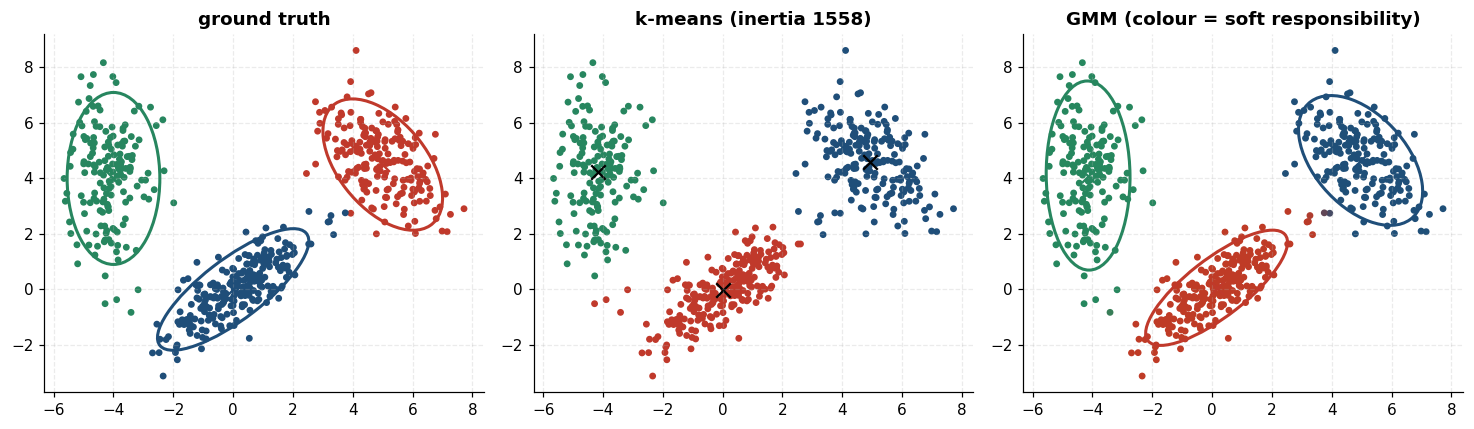

In [3]:
centers, km_labels, inertia = kmeans(X, 3, random_state=0)
gmm = GaussianMixtureEM(n_components=3, random_state=0).fit(X)
gmm_labels = gmm.predict(X)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
axes[0].scatter(X[:, 0], X[:, 1], s=12, c=[PALETTE[k] for k in z_true])
plot_ellipses(means_true, covs_true, ax=axes[0])
axes[0].set_title("ground truth")

axes[1].scatter(X[:, 0], X[:, 1], s=12, c=[PALETTE[k] for k in km_labels])
axes[1].scatter(centers[:, 0], centers[:, 1], marker="x", s=90, c="k")
axes[1].set_title(f"k-means (inertia {inertia:.0f})")

responsibilities = gmm.predict_proba(X)
axes[2].scatter(X[:, 0], X[:, 1], s=12,
                c=responsibilities @ np.array([[0.12, 0.31, 0.47],
                                               [0.75, 0.23, 0.15],
                                               [0.15, 0.53, 0.37]]))
plot_ellipses(gmm.means_, gmm.covariances_, ax=axes[2])
axes[2].set_title("GMM (colour = soft responsibility)")
plt.tight_layout()
plt.show()

Colours in the right-hand panel are mixtures of the component colours, so points
in the overlap region are literally drawn in between: EM returns a *distribution*
over assignments, not a label.

## 2. The E-step and the M-step

**E-step** -- responsibilities are posterior probabilities:

$$\gamma_{ik} = \frac{\pi_k\,\mathcal{N}(x_i\mid\mu_k,\Sigma_k)}{\sum_j \pi_j\,\mathcal{N}(x_i\mid\mu_j,\Sigma_j)} .$$

**M-step** -- weighted maximum-likelihood updates with $N_k = \sum_i \gamma_{ik}$:

$$\pi_k = \frac{N_k}{n},\qquad
\mu_k = \frac{1}{N_k}\sum_i \gamma_{ik}x_i,\qquad
\Sigma_k = \frac{1}{N_k}\sum_i \gamma_{ik}(x_i-\mu_k)(x_i-\mu_k)^\top .$$

converged in 8 iterations
monotone increase: True


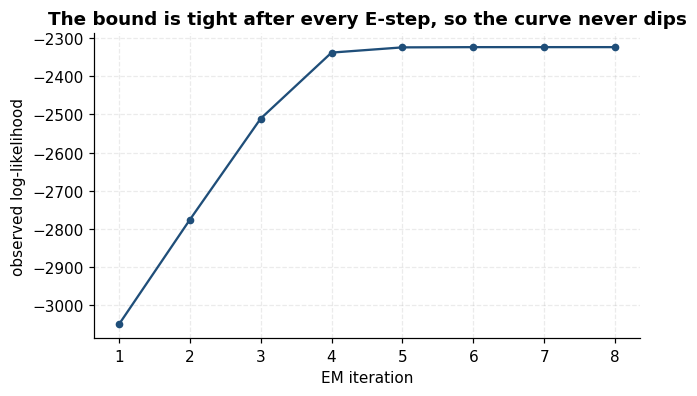


recovered parameters
  weight 0.27  mean [-4.15  4.1 ]
  weight 0.41  mean [0.15 0.06]
  weight 0.32  mean [4.96 4.65]
true
  weight 0.25  mean [-4.  4.]
  weight 0.45  mean [0. 0.]
  weight 0.30  mean [5.  4.5]


In [4]:
ll = np.asarray(gmm.log_likelihood_)
print(f"converged in {gmm.n_iter_} iterations")
print(f"monotone increase: {bool(np.all(np.diff(ll) > -1e-9))}")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(np.arange(1, len(ll) + 1), ll, "o-", ms=4)
ax.set_xlabel("EM iteration")
ax.set_ylabel("observed log-likelihood")
ax.set_title("The bound is tight after every E-step, so the curve never dips")
plt.show()

print("\nrecovered parameters")
order = np.argsort(gmm.means_[:, 0])
for k in order:
    print(f"  weight {gmm.weights_[k]:.2f}  mean {np.round(gmm.means_[k], 2)}")
print("true")
for k in np.argsort(means_true[:, 0]):
    print(f"  weight {[0.45, 0.3, 0.25][k]:.2f}  mean {means_true[k]}")

## 3. Initialisation matters: EM finds *a* local optimum

The likelihood surface of a mixture is multi-modal (and, with unconstrained
covariances, unbounded -- a component can collapse onto a single point). On the
well-separated data above every seed converges to the same solution, so we need
a harder problem to see the effect: four overlapping components.

init          best log-lik     worst   spread


random            -1379.54  -1385.35     5.81


kmeans++          -1378.15  -1385.67     7.52


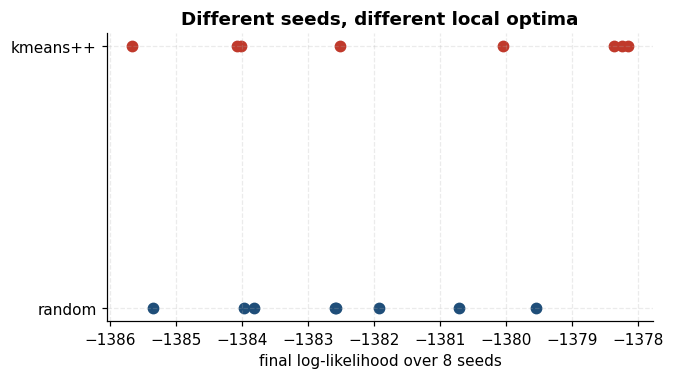

In [5]:
means_hard = np.array([[0.0, 0.0], [1.6, 0.9], [-1.2, 1.4], [0.6, -1.8]])
X_hard, _ = make_gaussian_mixture(400, means=means_hard,
                                  covs=np.stack([np.eye(2) * 0.9] * 4),
                                  weights=[0.3, 0.3, 0.2, 0.2], random_state=1)

print(f"{'init':<12}{'best log-lik':>14}{'worst':>10}{'spread':>9}")
finals = {}
for init in ["random", "kmeans++"]:
    values = [GaussianMixtureEM(n_components=4, init=init, random_state=seed)
              .fit(X_hard).log_likelihood_[-1] for seed in range(8)]
    finals[init] = values
    print(f"{init:<12}{max(values):>14.2f}{min(values):>10.2f}{np.ptp(values):>9.2f}")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
for i, (init, values) in enumerate(finals.items()):
    ax.scatter(values, np.full(len(values), i), s=45, label=init)
ax.set_yticks(range(len(finals)))
ax.set_yticklabels(list(finals))
ax.set_xlabel("final log-likelihood over 8 seeds")
ax.set_title("Different seeds, different local optima")
plt.show()

## 4. Choosing the number of components

The training likelihood is monotone in $K$, so it cannot select $K$. Penalised
criteria can: $\mathrm{BIC} = -2\log\hat L + k\log n$ charges $\log n$ per free
parameter, while AIC charges only 2 and therefore tends to over-select.

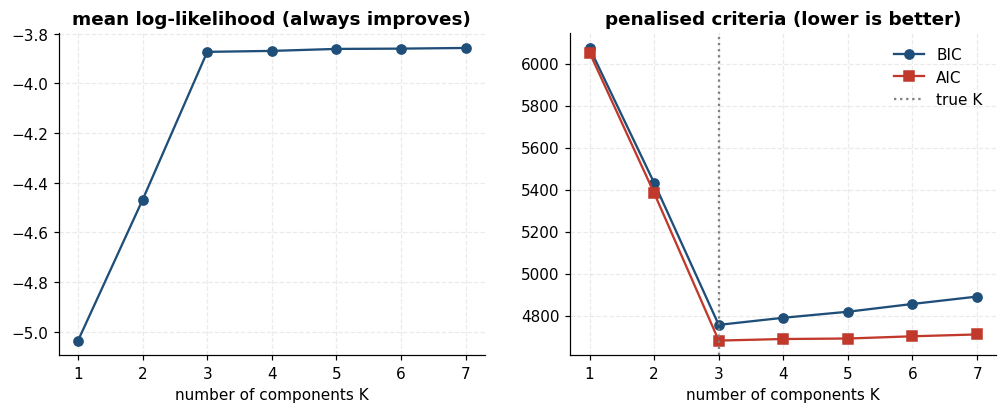

BIC selects K = 3, AIC selects K = 3


In [6]:
ks = range(1, 8)
bics, aics, lls = [], [], []
for k in ks:
    fit = GaussianMixtureEM(n_components=k, random_state=0).fit(X)
    bics.append(fit.bic(X))
    aics.append(fit.aic(X))
    lls.append(fit.score(X))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(list(ks), lls, "o-")
axes[0].set_title("mean log-likelihood (always improves)")
axes[1].plot(list(ks), bics, "o-", label="BIC")
axes[1].plot(list(ks), aics, "s-", label="AIC")
axes[1].axvline(3, color="grey", ls=":", label="true K")
axes[1].set_title("penalised criteria (lower is better)")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("number of components K")
plt.show()

print(f"BIC selects K = {list(ks)[int(np.argmin(bics))]}, "
      f"AIC selects K = {list(ks)[int(np.argmin(aics))]}")

## 5. A mixture is also a density model

Unlike k-means, a fitted GMM assigns a likelihood to any point, which makes it
usable for novelty detection: low `score_samples` means "unlike the training
distribution".

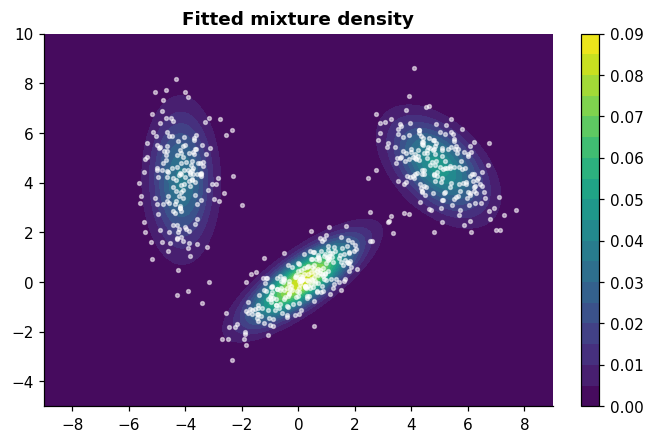

log-density at two far-away probe points: [-30.7 -28.8] vs. median on training data: -3.7
cluster accuracy after matching labels: 0.998


In [7]:
xx, yy = np.meshgrid(np.linspace(-9, 9, 220), np.linspace(-5, 10, 220))
density = gmm.score_samples(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.6, 4.4))
cs = ax.contourf(xx, yy, np.exp(density), levels=18, cmap="viridis")
ax.scatter(X[:, 0], X[:, 1], s=6, color="w", alpha=0.55)
ax.set_title("Fitted mixture density")
ax.grid(False)
fig.colorbar(cs, ax=ax, fraction=0.046)
plt.show()

outliers = np.array([[9.0, 9.0], [-8.0, -4.0]])
print("log-density at two far-away probe points:",
      np.round(gmm.score_samples(outliers), 1),
      "vs. median on training data:", round(float(np.median(gmm.score_samples(X))), 1))

# clustering agreement with the true labels (up to permutation)
mapping = {k: np.bincount(z_true[gmm_labels == k], minlength=3).argmax()
           for k in range(3)}
print("cluster accuracy after matching labels:",
      round(accuracy(z_true, np.array([mapping[k] for k in gmm_labels])), 3))

## 6. What to take away

1. EM is coordinate ascent on a lower bound; the E-step makes the bound tight,
   which is why the likelihood is monotone.
2. Responsibilities are soft assignments -- valuable information that hard
   clustering throws away.
3. The likelihood surface is multi-modal and, for unconstrained covariances,
   unbounded. Seeding changes which optimum you land in -- on separable data it
   makes no difference, on overlapping data it decides the answer -- so run
   several restarts, keep the best likelihood, and regularise the covariances.
4. Model selection needs a penalty (BIC) or held-out data -- never the training
   likelihood.

**Next:** notebook 06 changes regime completely: instead of a probabilistic
model fitted by EM, an ensemble built greedily, one weak learner at a time.